In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
import os
import shutil

# ======================================
# SAVE PATH
# ======================================

SAVE_DIR = "/content/drive/MyDrive/Sectorial_TC_Dataset"
os.makedirs(SAVE_DIR, exist_ok=True)

# ======================================
# GRID
# ======================================

N = 700
L = 50

dx = L/N

x = np.arange(-L/2, L/2, dx)
y = x

X, Y = np.meshgrid(x, y)

phi = np.arctan2(Y, X)
rho = np.sqrt(X**2 + Y**2)

phi_mod = np.mod(phi, 2*np.pi)

# ======================================
# PARAMETERS
# ======================================

w0 = 1.2

sector_width = np.pi/12
sector_center = np.pi/2

phi1 = sector_center - sector_width/2
phi2 = sector_center + sector_width/2

crop = 250

# ======================================
# DATASET GENERATION
# ======================================

for l in range(-20, 21):

    folder = os.path.join(
        SAVE_DIR,
        f"TC_{l}"
    )

    os.makedirs(folder, exist_ok=True)

    print(f"Generating TC {l}")

    for img_no in range(70):

        # sector rotation augmentation
        shift = np.deg2rad(
            np.random.uniform(-8, 8)
        )

        p1 = phi1 + shift
        p2 = phi2 + shift

        screen = np.ones_like(phi_mod)

        screen[
            (phi_mod >= p1)
            &
            (phi_mod <= p2)
        ] = 0

        # vortex beam
        E = (
            (rho/w0)**abs(l)
            *
            np.exp(-(rho**2)/(w0**2))
            *
            np.exp(1j*l*phi)
        )

        E_ap = E * screen

        Diff = fftshift(
            fft2(E_ap)
        )

        I = np.abs(Diff)**2

        I = I / np.max(I)

        c0 = N//2

        I_crop = I[
            c0-crop:c0+crop,
            c0-crop:c0+crop
        ]

        plt.figure(
            figsize=(5,5)
        )

        plt.imshow(
            I_crop,
            cmap='jet'
        )

        plt.axis('off')

        plt.savefig(
            os.path.join(
                folder,
                f"{img_no}.png"
            ),
            bbox_inches='tight',
            pad_inches=0
        )

        plt.close()

print("Dataset Generated")

# ======================================
# ZIP FILE
# ======================================

zip_path = "/content/drive/MyDrive/Sectorial_TC_Dataset"

shutil.make_archive(
    zip_path,
    'zip',
    SAVE_DIR
)

print("ZIP Saved:")
print(zip_path + ".zip")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generating TC -20
Generating TC -19
Generating TC -18
Generating TC -17
Generating TC -16
Generating TC -15
Generating TC -14
Generating TC -13
Generating TC -12
Generating TC -11
Generating TC -10
Generating TC -9
Generating TC -8
Generating TC -7
Generating TC -6
Generating TC -5
Generating TC -4
Generating TC -3
Generating TC -2
Generating TC -1
Generating TC 0
Generating TC 1
Generating TC 2
Generating TC 3
Generating TC 4
Generating TC 5
Generating TC 6
Generating TC 7
Generating TC 8
Generating TC 9
Generating TC 10
Generating TC 11
Generating TC 12
Generating TC 13
Generating TC 14
Generating TC 15
Generating TC 16
Generating TC 17
Generating TC 18
Generating TC 19
Generating TC 20
Dataset Generated
ZIP Saved:
/content/drive/MyDrive/Sectorial_TC_Dataset.zip


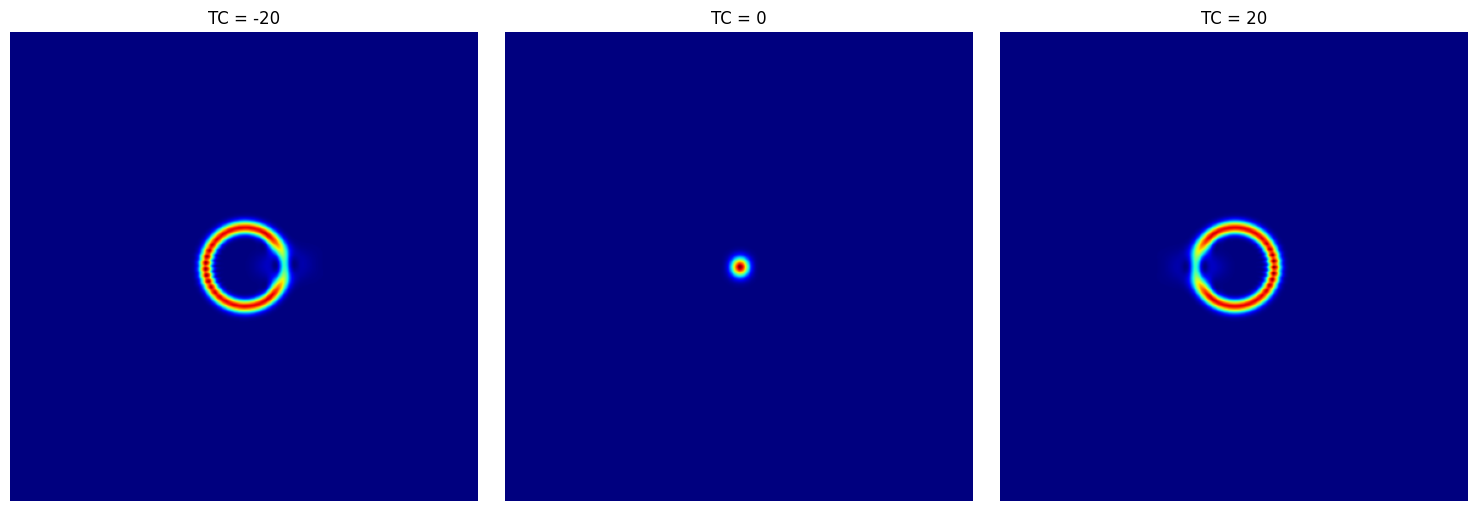

In [2]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/Sectorial_TC_Dataset"

tcs = [-20, 0, 20]

plt.figure(figsize=(15,5))

for i, tc in enumerate(tcs):

    folder = os.path.join(dataset_path, f"TC_{tc}")

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"TC = {tc}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/Sectorial_TC_Dataset"

labels = []

for folder in os.listdir(dataset_path):

    if folder.startswith("TC_"):

        tc = int(folder.replace("TC_", ""))
        labels.append(tc)

print("Min TC =", min(labels))
print("Max TC =", max(labels))
print("Total Classes =", len(labels))

Min TC = -20
Max TC = 20
Total Classes = 41


In [2]:
import os

dataset_path = "/content/drive/MyDrive/Sectorial_TC_Dataset"

for folder in sorted(os.listdir(dataset_path)):

    if folder.startswith("TC_"):

        count = len(os.listdir(os.path.join(dataset_path, folder)))

        print(folder, ":", count)

TC_-1 : 70
TC_-10 : 70
TC_-11 : 70
TC_-12 : 70
TC_-13 : 70
TC_-14 : 70
TC_-15 : 70
TC_-16 : 70
TC_-17 : 70
TC_-18 : 70
TC_-19 : 70
TC_-2 : 70
TC_-20 : 70
TC_-3 : 70
TC_-4 : 70
TC_-5 : 70
TC_-6 : 70
TC_-7 : 70
TC_-8 : 70
TC_-9 : 70
TC_0 : 70
TC_1 : 70
TC_10 : 70
TC_11 : 70
TC_12 : 70
TC_13 : 70
TC_14 : 70
TC_15 : 70
TC_16 : 70
TC_17 : 70
TC_18 : 70
TC_19 : 70
TC_2 : 70
TC_20 : 70
TC_3 : 70
TC_4 : 70
TC_5 : 70
TC_6 : 70
TC_7 : 70
TC_8 : 70
TC_9 : 70


X shape = (2870, 224, 224, 3)
y shape = (2870,)
Label range = -20.0 20.0
Train: (2296, 224, 224, 3)
Test : (574, 224, 224, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,329,089 (73.73 MB)

 Trainable params: 19,329,089 (73.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - loss: 0.1542 - mae: 0.2772 - val_loss: 0.0036 - val_mae: 0.0435 - learning_rate: 1.0000e-04
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 315s 3s/step - loss: 0.0034 - mae: 0.0446 - val_loss: 8.4348e-04 - val_mae: 0.0240 - learning_rate: 1.0000e-04
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 305s 3s/step - loss: 0.0019 - mae: 0.0333 - val_loss: 3.7050e-04 - val_mae: 0.0153 - learning_rate: 1.0000e-04
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 305s 3s/step - loss: 0.0014 - mae: 0.0286 - val_loss: 9.8746e-04 - val_mae: 0.0232 - learning_rate: 1.0000e-04
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - loss: 0.0014 - mae: 0.0282 - val_loss: 8.4930e-04 - val_mae: 0.0221 - learning_rate: 1.0000e-04
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - loss: 0.0012 - mae: 0.0259 - val_loss: 1.3211e-04 - val_mae: 0.0080 - learning_rate: 1.0000e-04
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 307s 3s/step - loss: 0.0011 - mae: 0.0249 - val_loss: 7.02

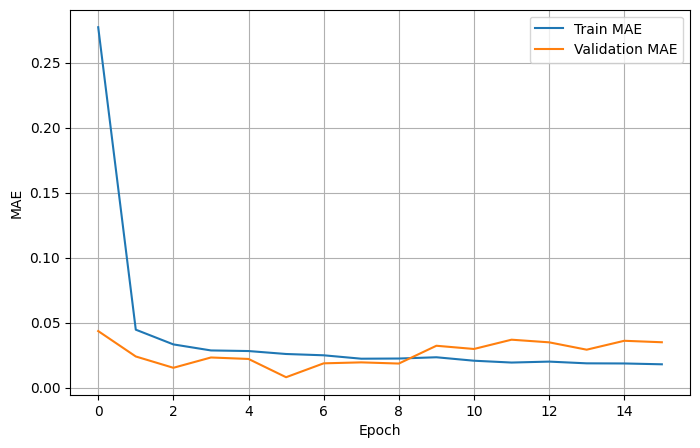

In [3]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# ==================================================
# DATASET PATH
# ==================================================

DATASET_PATH = "/content/drive/MyDrive/Sectorial_TC_Dataset"

IMG_SIZE = 224

X = []
y = []

# ==================================================
# LOAD DATASET
# ==================================================

for folder in sorted(os.listdir(DATASET_PATH)):

    if not folder.startswith("TC_"):
        continue

    tc = int(folder.replace("TC_", ""))

    folder_path = os.path.join(DATASET_PATH, folder)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = img.astype(np.float32) / 255.0

        X.append(img)
        y.append(tc)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print("X shape =", X.shape)
print("y shape =", y.shape)
print("Label range =", y.min(), y.max())

# ==================================================
# TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# ==================================================
# NORMALIZE LABELS
# ==================================================

y_train_norm = y_train / 20.0
y_test_norm = y_test / 20.0

# ==================================================
# CNN MODEL
# ==================================================

model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        256,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        512,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1,
        activation='tanh'
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==================================================
# CALLBACKS
# ==================================================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        save_best_only=True,
        monitor="val_mae"
    ),

    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        patience=4,
        factor=0.5
    )
]

# ==================================================
# TRAIN
# ==================================================

history = model.fit(
    X_train,
    y_train_norm,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=callbacks
)

# ==================================================
# PREDICTION
# ==================================================

pred_norm = model.predict(X_test).flatten()

pred = pred_norm * 20.0

mae = mean_absolute_error(
    y_test,
    pred
)

print("\nFinal MAE =", mae)

# ==================================================
# SAMPLE RESULTS
# ==================================================

for i in range(20):

    print(
        f"True={y_test[i]:.0f}   Pred={pred[i]:.2f}"
    )

# ==================================================
# MAE PLOT
# ==================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['mae'],
    label='Train MAE'
)

plt.plot(
    history.history['val_mae'],
    label='Validation MAE'
)

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid()

plt.show()

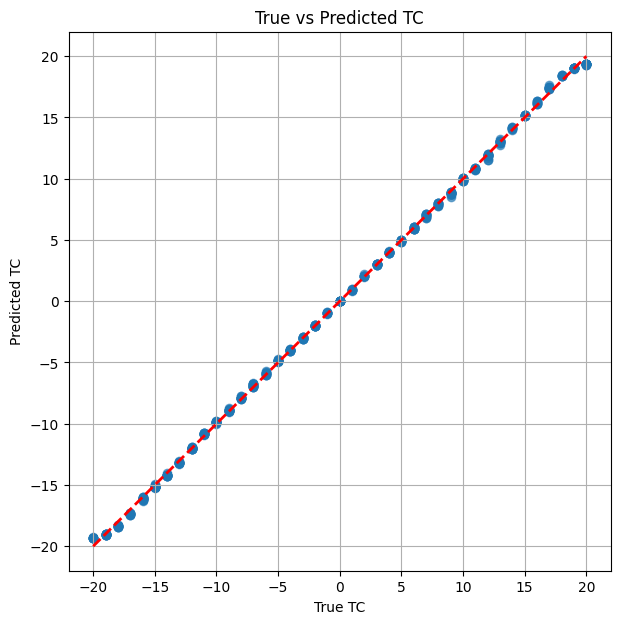

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, pred, alpha=0.6)

plt.plot(
    [-20,20],
    [-20,20],
    'r--',
    linewidth=2
)

plt.xlabel("True TC")
plt.ylabel("Predicted TC")
plt.title("True vs Predicted TC")

plt.grid(True)

plt.show()

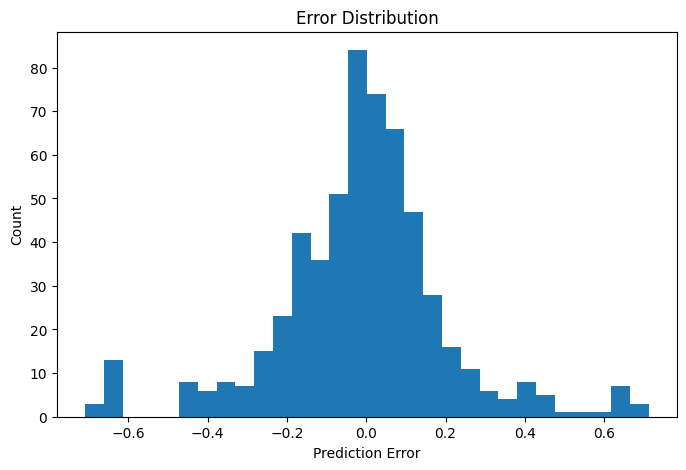

In [5]:
errors = pred - y_test

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Error Distribution")

plt.show()

In [6]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, pred)

print("R² =", r2)

R² = 0.9996564388275146


In [8]:
model.save("sectorial_tc_model.keras")
model.save("/content/drive/MyDrive/sectorial_tc_model.keras")

In [13]:
import cv2
import numpy as np
import tensorflow as tf

model = tf.keras.models.load_model(
    "sectorial_tc_model.keras"
)

img = cv2.imread("/content/drive/MyDrive/Sectorial_TC_Dataset/TC_-11/11.png")
img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img = cv2.resize(
    img,
    (224,224)
)

img = img.astype(np.float32)/255.0

img = np.expand_dims(
    img,
    axis=0
)
pred_norm = model.predict(img)[0][0]
pred_tc = pred_norm * 20
print("Predicted TC =", pred_tc)
print("Rounded TC =", round(pred_tc))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
Predicted TC = -10.783913
Rounded TC = -11


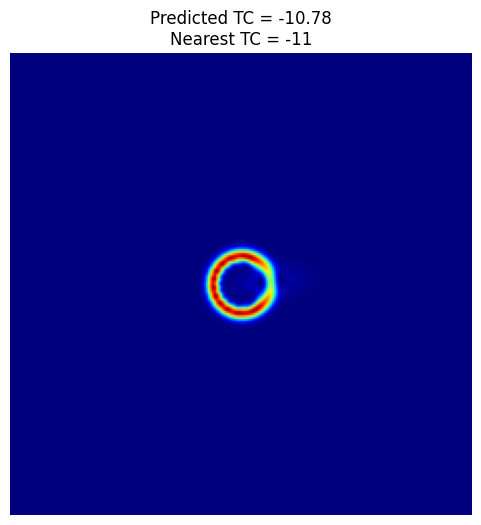

In [16]:
plt.figure(figsize=(6,6))

plt.imshow(img[0])

plt.title(
    f"Predicted TC = {pred_tc:.2f}\n"
    f"Nearest TC = {round(pred_tc)}"
)

plt.axis("off")

plt.show()